# Step 1: Data Preparation
One of the main reasons bounding boxes are inaccurate right now is because the CSV has **multiple bounding boxes per image** for some images. If you do simple regression (predicting 4 values) on an image that has multiple targets, the model gets contradictory training signals.

In this notebook, we group boxes by image and extract the **largest bounding box** (the most prominent car) so our regression model has a consistent target.

In [1]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# Load original data
csv_path = '../data/train_solution_bounding_boxes.csv'
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()
print(f"Original entries: {len(df)}")
df.head()

Original entries: 559


,image,xmin,ymin,xmax,ymax
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422


In [2]:
# Calculate bounding box area
df['area'] = (df['xmax'] - df['xmin']) * (df['ymax'] - df['ymin'])

# Sort by area descending, then group by image and take the first (largest)
df_clean = df.sort_values('area', ascending=False).groupby('image', sort=False).first().reset_index()

print(f"Unique images (cleaned entries): {len(df_clean)}")
df_clean.head()

Unique images (cleaned entries): 355


,image,xmin,ymin,xmax,ymax,area
0,vid_4_12480.jpg,22.500724,166.494530,309.629522,303.920528,39458.961587
1,vid_4_17320.jpg,262.182344,176.764801,561.050651,308.322072,39318.299010
2,vid_4_14140.jpg,343.869754,182.144466,616.324168,285.825290,28248.298054
3,vid_4_700.jpg,250.442836,197.305341,510.179450,283.379987,22356.737069
4,vid_4_720.jpg,283.801749,194.004540,530.650146,278.777562,20926.084547


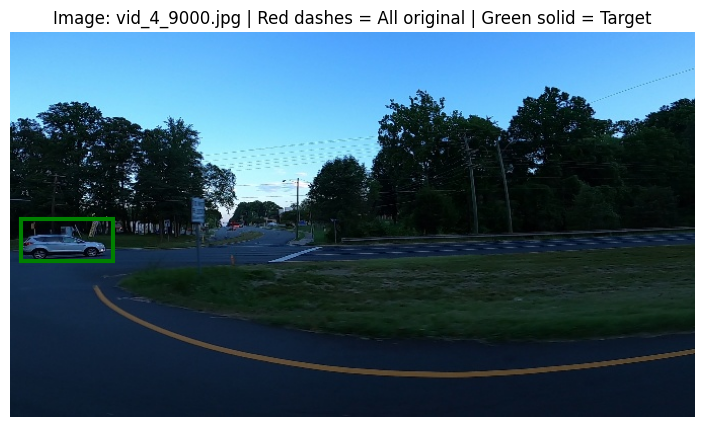

In [3]:
# Visualize the difference
import random
img_dir = '../data/training_images'
sample_img = random.choice(df_clean['image'].values)

img_path = os.path.join(img_dir, sample_img)
if os.path.exists(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Original boxes (could be multiple)
    orig_boxes = df[df['image'] == sample_img]
    clean_box = df_clean[df_clean['image'] == sample_img].iloc[0]
    
    plt.figure(figsize=(10, 5))
    plt.imshow(img)
    ax = plt.gca()
    
    # Draw all original boxes in red dotted
    for _, row in orig_boxes.iterrows():
        rect = plt.Rectangle((row['xmin'], row['ymin']), row['xmax'] - row['xmin'], row['ymax'] - row['ymin'], 
                             fill=False, edgecolor='red', linestyle='--', linewidth=2)
        ax.add_patch(rect)
        
    # Draw chosen (largest) box in green solid
    rect = plt.Rectangle((clean_box['xmin'], clean_box['ymin']), clean_box['xmax'] - clean_box['xmin'], clean_box['ymax'] - clean_box['ymin'], 
                         fill=False, edgecolor='green', linewidth=3)
    ax.add_patch(rect)
    
    plt.title(f"Image: {sample_img} | Red dashes = All original | Green solid = Target")
    plt.axis('off')
    plt.show()

In [4]:
# Save the cleaned dataset for training
cleaned_csv_path = '../data/cleaned_bounding_boxes.csv'
df_clean.to_csv(cleaned_csv_path, index=False)
print(f"Cleaned dataset saved to {cleaned_csv_path}")

Cleaned dataset saved to ../data/cleaned_bounding_boxes.csv
